# 02 — LSTM: Short-Term Electricity Demand Forecasting
### 96 past timesteps (24h) → 48 future timesteps (12h), 15-minute resolution

**Owner:** Member 3 · **Repo:** `Short-Term-electricity-demand-forcasting-`

This notebook is a single top-to-bottom flow. Run every cell in order, once, with no need to go
back and re-run earlier cells. It uses the repository's already-processed
`data/processed/train.csv`, `validation.csv`, `test.csv` — it does not re-run the repo's raw
preprocessing (`src/preprocess_electricity.py`, `src/merge_electricity_weather.py`,
`src/create_splits.py`), it builds on top of their output.

**Known data issue confirmed before writing this notebook:** `train.csv` has a 31-day gap —
**May 2022 is entirely missing** (there is no `May 2022.xlsx` in `data/raw/electricity/`).
Section 9 (sequence construction) explicitly detects and skips any 144-step window that would
cross this gap, rather than silently treating April 30 → June 1 as consecutive timestamps.


## 1. Imports

In [2]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow:", tf.__version__)
print("GPUs visible to TensorFlow:", tf.config.list_physical_devices("GPU"))
# Expected on your machine: an empty list — this notebook is written for CPU-only training.


TensorFlow: 2.21.0
GPUs visible to TensorFlow: []


## 2. Configuration

Every "magic number" used later lives here, defined once. Nothing downstream redefines these.


In [3]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = "../data/processed"          # adjust if this notebook's location differs
MODEL_OUT_DIR = "../models/lstm"        # where trained artifacts are saved (Section 18)

TARGET_COL = "NLDC_DEMAND"

LOOKBACK = 96    # 24 hours of history at 15-minute resolution  -> 96 steps
HORIZON = 48     # 12 hours forecast at 15-minute resolution    -> 48 steps
WINDOW = LOOKBACK + HORIZON

SEASON = 96      # used only for the MASE naive baseline: "same time yesterday"

BATCH_SIZE = 64
MAX_EPOCHS = 50          # EarlyStopping will almost always stop well before this
EARLY_STOP_PATIENCE = 5

os.makedirs(MODEL_OUT_DIR, exist_ok=True)
print(f"LOOKBACK={LOOKBACK}, HORIZON={HORIZON}, WINDOW={WINDOW}")


LOOKBACK=96, HORIZON=48, WINDOW=144


## 3. Load dataset

Loads the three CSVs exactly as committed in the repo. **What it does:** reads
`train.csv` / `validation.csv` / `test.csv`, parses `timestamp`, and sorts chronologically
(defensive — they are already sorted, but this guarantees it).
**Input:** the three CSV files. **Output:** three DataFrames, one row per 15-minute interval.


In [4]:
train_df = pd.read_csv(f"{DATA_DIR}/train.csv", parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
val_df   = pd.read_csv(f"{DATA_DIR}/validation.csv", parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
test_df  = pd.read_csv(f"{DATA_DIR}/test.csv", parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

for name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(f"{name:10s} shape={df.shape}  range={df['timestamp'].min()} -> {df['timestamp'].max()}")


train      shape=(14400, 33)  range=2022-01-01 00:00:00 -> 2022-06-30 23:45:00
validation shape=(2976, 33)  range=2022-07-01 00:00:00 -> 2022-07-31 23:45:00
test       shape=(5856, 33)  range=2022-08-01 00:00:00 -> 2022-09-30 23:45:00


## 4. Inspect dataset

Confirms the facts this notebook is built around, directly from the loaded data, rather than
assuming them. **Expect:** train 14,400 rows / 33 columns, validation 2,976 rows, test 5,856 rows;
zero nulls in any split (the repo's preprocessing already removed them).


In [5]:
for name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    n_missing = df.isna().sum().sum()
    n_dupe_ts = df["timestamp"].duplicated().sum()
    print(f"{name:10s} missing_values={n_missing}  duplicate_timestamps={n_dupe_ts}")

print("\nColumns:", list(train_df.columns))
print("\nTarget summary (train):")
print(train_df[TARGET_COL].describe())


train      missing_values=0  duplicate_timestamps=0
validation missing_values=0  duplicate_timestamps=0
test       missing_values=0  duplicate_timestamps=0

Columns: ['timestamp', 'NLDC_DEMAND', 'hour', 'minute', 'day_of_week', 'day_of_month', 'month', 'is_weekend', 'delhi_T2M', 'delhi_RH2M', 'delhi_SOLAR', 'delhi_WS10M', 'delhi_PRECIP', 'mumbai_T2M', 'mumbai_RH2M', 'mumbai_SOLAR', 'mumbai_WS10M', 'mumbai_PRECIP', 'bengaluru_T2M', 'bengaluru_RH2M', 'bengaluru_SOLAR', 'bengaluru_WS10M', 'bengaluru_PRECIP', 'kolkata_T2M', 'kolkata_RH2M', 'kolkata_SOLAR', 'kolkata_WS10M', 'kolkata_PRECIP', 'guwahati_T2M', 'guwahati_RH2M', 'guwahati_SOLAR', 'guwahati_WS10M', 'guwahati_PRECIP']

Target summary (train):
count     14400.000000
mean     171181.254629
std       20385.006097
min       59623.010417
25%      161509.144531
50%      176561.395833
75%      185377.544271
max      211577.385417
Name: NLDC_DEMAND, dtype: float64


In [6]:
# Confirm the actual sampling gaps in each split — this is what surfaces the missing-May issue.
for name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    diffs = df["timestamp"].diff().dropna()
    gaps = diffs[diffs != pd.Timedelta(minutes=15)]
    print(f"{name:10s}: {len(gaps)} non-15-minute gap(s)")
    for idx, size in gaps.items():
        print(f"   gap at row {idx}: {df.loc[idx-1,'timestamp']} -> {df.loc[idx,'timestamp']}  (size={size})")


train     : 1 non-15-minute gap(s)
   gap at row 11520: 2022-04-30 23:45:00 -> 2022-06-01 00:00:00  (size=31 days 00:15:00)
validation: 0 non-15-minute gap(s)
test      : 0 non-15-minute gap(s)


**Expected output:** train shows exactly one gap, between `2022-04-30 23:45:00` and
`2022-06-01 00:00:00` (31 days). Validation and test show zero gaps. This is a property of the
raw data (May's source Excel file is absent from the repo), not a bug in this notebook — Section 9
is written to handle it correctly rather than ignore it.


## 5. Prepare timestamps

`timestamp` is already a proper `datetime64` column (parsed in Section 3) and the rows are
already sorted chronologically. This section exists only to make that guarantee explicit and
to extract `hour`/`minute`/`day_of_week` directly from the timestamp as a cross-check against the
repo's own precomputed `hour`, `minute`, `day_of_week` columns — catching any silent mismatch
before it propagates into feature engineering.


In [7]:
def timestamp_crosscheck(df, name):
    mismatch_hour = (df["timestamp"].dt.hour != df["hour"]).sum()
    mismatch_minute = (df["timestamp"].dt.minute != df["minute"]).sum()
    mismatch_dow = (df["timestamp"].dt.dayofweek != df["day_of_week"]).sum()
    print(f"{name:10s} hour_mismatches={mismatch_hour} minute_mismatches={mismatch_minute} dow_mismatches={mismatch_dow}")

for name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    timestamp_crosscheck(df, name)
# Expected: all zeros — the repo's precomputed calendar columns agree with the timestamp.


train      hour_mismatches=0 minute_mismatches=0 dow_mismatches=0
validation hour_mismatches=0 minute_mismatches=0 dow_mismatches=0
test       hour_mismatches=0 minute_mismatches=0 dow_mismatches=0


## 6. Feature engineering

**What:** adds cyclical (sine/cosine) encodings for time-of-day and day-of-week.
**Why:** `hour=23` and `hour=0` are one step apart in real time but maximally far apart as raw
integers — an LSTM has to learn that wraparound from scratch. Sine/cosine encoding places
`23:45` and `00:00` next to each other in feature space, which is the actual relationship.
The same applies to `day_of_week` (Sunday=6 and Monday=0 are adjacent days).

We encode **time-of-day in minutes** (`hour*60 + minute`), not just `hour`, so the model keeps
the 15-minute resolution instead of collapsing every quarter-hour inside an hour together.

`day_of_month` and `month` are left as plain (scaled) numbers rather than cyclically encoded —
the project only spans Jan–Sep 2022, so there's no winter→January wraparound in this data to
model, and day-of-month doesn't have the same circular relationship hour-of-day does.

After this step, the raw `hour`, `minute`, `day_of_week` columns are dropped from the model's
feature list (not from the DataFrame) because they're now redundant with their cyclical versions.


In [8]:
def add_cyclical_features(df):
    df = df.copy()
    minutes_of_day = df["hour"] * 60 + df["minute"]
    df["time_of_day_sin"] = np.sin(2 * np.pi * minutes_of_day / 1440)
    df["time_of_day_cos"] = np.cos(2 * np.pi * minutes_of_day / 1440)
    df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
    return df

train_df = add_cyclical_features(train_df)
val_df   = add_cyclical_features(val_df)
test_df  = add_cyclical_features(test_df)

train_df[["timestamp","hour","minute","time_of_day_sin","time_of_day_cos","day_of_week","dow_sin","dow_cos"]].head(3)


,timestamp,hour,minute,time_of_day_sin,time_of_day_cos,day_of_week,dow_sin,dow_cos
0,2022-01-01 00:00:00,0,0,0.000000,1.000000,5,-0.974928,-0.222521
1,2022-01-01 00:15:00,0,15,0.065403,0.997859,5,-0.974928,-0.222521
2,2022-01-01 00:30:00,0,30,0.130526,0.991445,5,-0.974928,-0.222521


## 7. Define features and target

**Leakage check for the weather columns (important — read this):** `merge_electricity_weather.py`
builds the weather columns with `pd.merge_asof(..., direction="backward")` against NASA POWER
**hourly historical observations** (actual measured weather, not a forecast product). That means
`delhi_T2M` at any given row is the most recent *already-observed* reading at or before that
timestamp — safe to use as a feature describing the past, exactly like `NLDC_DEMAND` itself.

**What we must never do:** use a weather value whose timestamp falls inside the 48-step forecast
window as an input. That would mean feeding the model the actual future weather to predict the
future demand — leakage, since in a real deployment you would not have tomorrow's *observed*
weather, only a forecast of it (a different, less certain quantity this dataset does not contain).

This notebook's design avoids the issue structurally: **every input feature, for every sample,
comes only from the 96 past timesteps.** The model never receives any value — demand or weather —
timestamped at or after the forecast start. No separate leakage filtering step is needed later
because the sequence-construction logic in Section 9 enforces this by construction.


In [9]:
WEATHER_CITY_PREFIXES = ["delhi_", "mumbai_", "bengaluru_", "kolkata_", "guwahati_"]
WEATHER_COLS = [c for c in train_df.columns if any(c.startswith(p) for p in WEATHER_CITY_PREFIXES)]

CYCLICAL_COLS = ["time_of_day_sin", "time_of_day_cos", "dow_sin", "dow_cos"]
OTHER_TIME_COLS = ["is_weekend", "day_of_month", "month"]

# Target is included as a feature too: its own recent history is one of the strongest predictors
# of near-future demand, and the LSTM needs it in the input sequence to learn that.
FEATURE_COLUMNS = [TARGET_COL] + CYCLICAL_COLS + OTHER_TIME_COLS + WEATHER_COLS

print(f"Number of input features per timestep: {len(FEATURE_COLUMNS)}")
print(FEATURE_COLUMNS)


Number of input features per timestep: 33
['NLDC_DEMAND', 'time_of_day_sin', 'time_of_day_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'day_of_month', 'month', 'delhi_T2M', 'delhi_RH2M', 'delhi_SOLAR', 'delhi_WS10M', 'delhi_PRECIP', 'mumbai_T2M', 'mumbai_RH2M', 'mumbai_SOLAR', 'mumbai_WS10M', 'mumbai_PRECIP', 'bengaluru_T2M', 'bengaluru_RH2M', 'bengaluru_SOLAR', 'bengaluru_WS10M', 'bengaluru_PRECIP', 'kolkata_T2M', 'kolkata_RH2M', 'kolkata_SOLAR', 'kolkata_WS10M', 'kolkata_PRECIP', 'guwahati_T2M', 'guwahati_RH2M', 'guwahati_SOLAR', 'guwahati_WS10M', 'guwahati_PRECIP']


## 8. Scale data

**Why scaling is required:** LSTM gates use sigmoid/tanh activations that saturate for large
inputs; and `NLDC_DEMAND` (~150,000-200,000) sits on a completely different numeric scale than
`is_weekend` (0/1) or `dow_sin` (-1 to 1). Without scaling, the loss surface is dominated by the
demand column and training converges poorly or not at all.

**Two separate scalers, fit on TRAIN ONLY (data-leakage rule):**
- `target_scaler` — fit only on `NLDC_DEMAND` from `train_df`. Used both to scale `NLDC_DEMAND`
  wherever it appears as an input feature, and to inverse-transform predictions back to real MW
  later (Section 15). Using one scaler for both roles keeps them consistent.
- `feature_scaler` — fit only on the weather columns + `day_of_month` + `month` from `train_df`.
  Cyclical features (`*_sin`, `*_cos`) are already bounded in [-1, 1] and `is_weekend` is already
  {0, 1}, so neither needs scaling.

`validation_df` and `test_df` are only ever *transformed* with these already-fitted scalers,
never refit — fitting on validation/test would leak their distribution into training.


In [10]:
CONTINUOUS_SCALE_COLS = ["day_of_month", "month"] + WEATHER_COLS

target_scaler = MinMaxScaler()
target_scaler.fit(train_df[[TARGET_COL]])

feature_scaler = MinMaxScaler()
feature_scaler.fit(train_df[CONTINUOUS_SCALE_COLS])

def scale_split(df):
    df = df.copy()
    df[[TARGET_COL]] = target_scaler.transform(df[[TARGET_COL]])
    df[CONTINUOUS_SCALE_COLS] = feature_scaler.transform(df[CONTINUOUS_SCALE_COLS])
    return df

train_scaled = scale_split(train_df)
val_scaled   = scale_split(val_df)
test_scaled  = scale_split(test_df)

print("Scaled NLDC_DEMAND range (train):", train_scaled[TARGET_COL].min(), "to", train_scaled[TARGET_COL].max())
print("Scaled NLDC_DEMAND range (test, can exceed [0,1] — that's expected and fine):",
      test_scaled[TARGET_COL].min(), "to", test_scaled[TARGET_COL].max())


Scaled NLDC_DEMAND range (train): 0.0 to 1.0
Scaled NLDC_DEMAND range (test, can exceed [0,1] — that's expected and fine): 0.42652893343807996 to 0.9211398432369367


## 9. Create sequences

This is the most important correctness-critical cell in the notebook — read it carefully.

**The transformation, concretely:** raw tabular data of shape `(n_rows, n_features)` becomes a
3D array of shape `(n_samples, 96, n_features)` for input and `(n_samples, 48)` for target.

**How one training sample is built**, e.g. the very first valid sample in `train_scaled`:
- `X[0]` = rows **0 to 95** (96 consecutive 15-minute rows: `2022-01-01 00:00` to `2022-01-01 23:45`)
  of every column in `FEATURE_COLUMNS` → shape `(96, 33)`
- `y[0]` = the `NLDC_DEMAND` values at rows **96 to 143** (`2022-01-02 00:00` to `2022-01-02 11:45`,
  the next 12 hours) → shape `(48,)`
- The next sample slides forward by **one row** (15 minutes): `X[1]` = rows 1-96, `y[1]` = rows 97-144.
  This is a standard sliding window with stride 1, which is why 14,400 raw rows produce roughly
  14,400 − 144 ≈ 14,256 candidate samples (before the gap check below removes a few more).

**Why the gap check matters:** Section 4 found that `train_df` jumps from 2022-04-30 23:45 to
2022-06-01 00:00 with no data in between. A plain slide over row *indices* (ignoring the actual
timestamps) would build a "window" whose first 96 rows are April and whose last 48 rows are June,
and silently label it as "24 hours of history predicting the next 12 hours" — which it is not.
The function below checks the *real elapsed time* across every window and discards any window
that is not a perfectly regular, gap-free run of 15-minute steps.


In [11]:
def make_sequences(df, lookback=LOOKBACK, horizon=HORIZON, feature_cols=FEATURE_COLUMNS, target_col=TARGET_COL):
    window = lookback + horizon
    timestamps = df["timestamp"].values.astype("datetime64[m]")

    # is_gap[i] = True if row i does NOT follow row i-1 by exactly 15 minutes (row 0 is trivially fine)
    is_gap = np.zeros(len(df), dtype=bool)
    is_gap[1:] = (timestamps[1:] - timestamps[:-1]) != np.timedelta64(15, "m")
    gap_prefix_count = np.cumsum(is_gap.astype(int))  # running count of gap-boundaries up to & incl. row i

    feats = df[feature_cols].to_numpy(dtype="float32")
    target = df[target_col].to_numpy(dtype="float32")

    n_rows = len(df)
    X_list, y_list = [], []
    skipped = 0

    for start in range(0, n_rows - window + 1):
        end = start + window - 1
        # Window [start, end] is gap-free iff no gap-boundary falls strictly inside it, i.e.
        # the count of gap-boundaries at positions (start, end] is zero.
        if gap_prefix_count[end] - gap_prefix_count[start] == 0:
            X_list.append(feats[start : start + lookback])
            y_list.append(target[start + lookback : start + window])
        else:
            skipped += 1

    X = np.stack(X_list)
    y = np.stack(y_list)
    print(f"  rows={n_rows}  window={window}  valid_sequences={len(X)}  skipped_for_gap={skipped}")
    return X, y

print("Building TRAIN sequences:")
X_train, y_train = make_sequences(train_scaled)
print("Building VALIDATION sequences:")
X_val, y_val = make_sequences(val_scaled)
print("Building TEST sequences:")
X_test, y_test = make_sequences(test_scaled)


Building TRAIN sequences:
  rows=14400  window=144  valid_sequences=14114  skipped_for_gap=143
Building VALIDATION sequences:
  rows=2976  window=144  valid_sequences=2833  skipped_for_gap=0
Building TEST sequences:
  rows=5856  window=144  valid_sequences=5713  skipped_for_gap=0


**Expected output:** train reports `skipped_for_gap=143` (the May gap), validation and test
report `skipped_for_gap=0` (both are gap-free already, confirmed in Section 4).


## 10. Verify shapes

A single, unambiguous checkpoint before building the model. If any assertion here fails, stop
and re-check Sections 7–9 rather than proceeding — a silent shape mismatch is the most common
source of confusing errors later (see Troubleshooting in the master document).


In [12]:
N_FEATURES = len(FEATURE_COLUMNS)

assert X_train.shape[1:] == (LOOKBACK, N_FEATURES), X_train.shape
assert y_train.shape[1:] == (HORIZON,), y_train.shape
assert X_val.shape[1:] == (LOOKBACK, N_FEATURES)
assert X_test.shape[1:] == (LOOKBACK, N_FEATURES)
assert len(X_train) == len(y_train)
assert len(X_val) == len(y_val)
assert len(X_test) == len(y_test)

print("X_train", X_train.shape, " y_train", y_train.shape)
print("X_val  ", X_val.shape,   " y_val  ", y_val.shape)
print("X_test ", X_test.shape,  " y_test ", y_test.shape)
print("\nAll shape checks passed.")


X_train (14114, 96, 33)  y_train (14114, 48)
X_val   (2833, 96, 33)  y_val   (2833, 48)
X_test  (5713, 96, 33)  y_test  (5713, 48)

All shape checks passed.


## 11. Build LSTM

**Architecture choice:** direct multi-output forecasting — a stacked LSTM encoder reads the 96-step
input sequence, and a single `Dense(48)` layer outputs all 48 future values **at once**, in one
forward pass. This is chosen over an encoder-decoder/seq2seq design (which would decode one step
at a time, feeding each prediction back in) because direct multi-output is simpler, trains faster
on CPU, has no error-accumulation-across-steps problem, and is a completely standard, defensible
choice for a fixed 48-step horizon in a student project. Encoder-decoder is noted as a Phase 8
("hyperparameter/architecture improvement") option, not the main path.

**Layer-by-layer:**
- `Input(shape=(96, 33))` — modern Keras style; avoids the deprecated `input_shape=` argument on
  the first LSTM layer, which the project's TensorFlow 2.21 environment flags as legacy usage.
- `LSTM(64, return_sequences=True)` — first recurrent layer, emits its hidden state at every one
  of the 96 timesteps (`return_sequences=True`) so the second LSTM layer has a full sequence to
  read rather than only the final summary.
- `Dropout(0.2)` — randomly zeroes 20% of activations during training only, a standard
  regularizer that discourages the network from over-relying on any single unit.
- `LSTM(32)` — second recurrent layer, `return_sequences` defaults to `False`, so it collapses
  the sequence to one final hidden-state vector summarizing all 96 input steps.
- `Dropout(0.2)` — same purpose as above.
- `Dense(48)` — maps the summary vector to 48 output values, one per future 15-minute step, in a
  single shot. No activation function (linear output), because the target is a continuous,
  unbounded-after-scaling-inverse quantity, not a probability or bounded value.

**Why these sizes:** 64 → 32 units keeps total trainable parameters under 40k, which trains in
roughly 10-15 seconds per epoch on a CPU for ~14k training sequences in this environment — small
enough to iterate on, large enough to have real capacity to learn daily/weekly demand patterns
plus weather effects. These are starting hyperparameters, not proven-optimal ones; Phase 8 is
where you would try alternatives (more units, an extra layer, GRU instead of LSTM, etc.) and
compare against this baseline using validation loss.


In [13]:
def build_lstm_model(lookback, n_features, horizon):
    inputs = Input(shape=(lookback, n_features), name="input_sequence")
    x = LSTM(64, return_sequences=True, name="lstm_1")(inputs)
    x = Dropout(0.2, name="dropout_1")(x)
    x = LSTM(32, name="lstm_2")(x)
    x = Dropout(0.2, name="dropout_2")(x)
    outputs = Dense(horizon, name="forecast_output")(x)

    model = Model(inputs, outputs, name="lstm_demand_forecaster")
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

model = build_lstm_model(LOOKBACK, N_FEATURES, HORIZON)
model.summary()


Model: "lstm_demand_forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_sequence (InputLayer)          │ (None, 96, 33)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 96, 64)              │          25,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 96, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ forecast_output (Dense)              │ (None, 48)                  │           1,584 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 39,088 (152.69 KB)

 Trainable params: 39,088 (152.69 KB)

 Non-trainable params: 0 (0.00 B)

## 12. Train LSTM

**What happens inside `model.fit()`, in plain terms:**
- An **epoch** is one full pass over every training sequence.
- Each epoch is split into **batches** of `BATCH_SIZE=64` sequences at a time.
- For each batch: the model makes a **forward pass** (runs the 96-step input through both LSTM
  layers and the Dense layer to produce 48 predicted values), computes the **loss** (mean squared
  error between predicted and actual scaled demand), then **backpropagation through time** computes
  how much each weight — including the recurrent weights that are reused at every one of the 96
  timesteps — contributed to that error, and the **Adam optimizer** nudges every weight slightly
  to reduce it.
- After each full epoch, the model is evaluated (no weight updates) on `X_val, y_val` — this
  **validation loss** is what tells you whether the model is generalizing or just memorizing
  the training sequences.
- **`EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)`** watches
  validation loss; if it hasn't improved for 5 consecutive epochs, training stops and the model's
  weights are rolled back to whichever epoch had the best validation loss — this removes the need
  to manually decide when to stop, and protects against overfitting past the point of diminishing
  returns.

**What the LSTM is actually learning:** recurring 15-minute-resolution demand patterns (daily
peak/off-peak cycles, weekday vs. weekend shape, how temperature/humidity shift that shape) encoded
in its weight matrices and gate parameters — not memorized values, but a function from "the last
24 hours of demand + calendar + weather" to "the next 12 hours of demand."


In [14]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOP_PATIENCE,
    restore_best_weights=True,
    verbose=1,
)

t0 = time.time()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=2,
)
train_time_sec = time.time() - t0
print(f"\nTraining stopped after {len(history.history['loss'])} epoch(s). Wall time: {train_time_sec:.1f}s")


Epoch 1/50
221/221 - 45s - 201ms/step - loss: 0.0770 - mae: 0.1991 - val_loss: 0.0124 - val_mae: 0.0657
Epoch 2/50
221/221 - 38s - 172ms/step - loss: 0.0174 - mae: 0.1037 - val_loss: 0.0123 - val_mae: 0.0652
Epoch 3/50
221/221 - 38s - 170ms/step - loss: 0.0122 - mae: 0.0862 - val_loss: 0.0140 - val_mae: 0.0753
Epoch 4/50
221/221 - 33s - 150ms/step - loss: 0.0097 - mae: 0.0768 - val_loss: 0.0137 - val_mae: 0.0742
Epoch 5/50
221/221 - 34s - 155ms/step - loss: 0.0083 - mae: 0.0704 - val_loss: 0.0119 - val_mae: 0.0637
Epoch 6/50
221/221 - 38s - 171ms/step - loss: 0.0071 - mae: 0.0653 - val_loss: 0.0107 - val_mae: 0.0566
Epoch 7/50
221/221 - 34s - 153ms/step - loss: 0.0064 - mae: 0.0616 - val_loss: 0.0113 - val_mae: 0.0604
Epoch 8/50
221/221 - 34s - 155ms/step - loss: 0.0056 - mae: 0.0575 - val_loss: 0.0112 - val_mae: 0.0596
Epoch 9/50
221/221 - 41s - 185ms/step - loss: 0.0052 - mae: 0.0549 - val_loss: 0.0109 - val_mae: 0.0591
Epoch 10/50
221/221 - 34s - 152ms/step - loss: 0.0047 - mae: 0.0

## 13. Plot training history

Compares training loss and validation loss per epoch. **How to read it:** both curves dropping
together and roughly tracking each other is healthy. Training loss dropping while validation loss
rises (or stays flat early then climbs) is overfitting — see Troubleshooting in the master document.


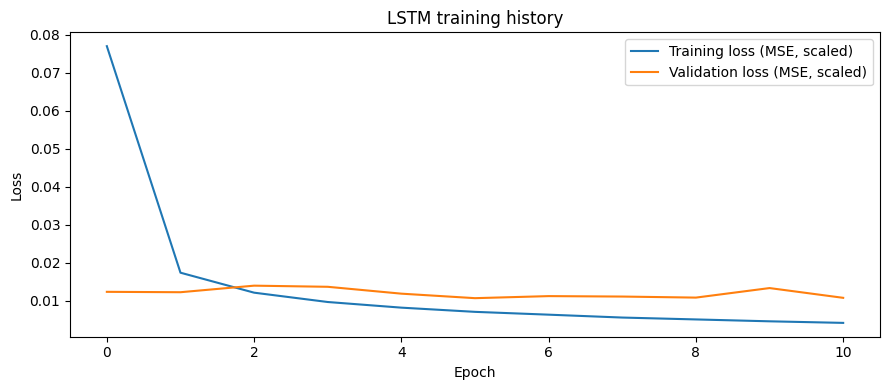

In [17]:
plt.figure(figsize=(9, 4))
plt.plot(history.history["loss"], label="Training loss (MSE, scaled)")
plt.plot(history.history["val_loss"], label="Validation loss (MSE, scaled)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM training history")
plt.legend()
plt.tight_layout()
plt.savefig(f"{MODEL_OUT_DIR}/training_history.png", dpi=120)
plt.show()


## 14. Predict test data

Runs the trained model once over the full, held-out test set (August-September 2022 — never
seen during training or used for early-stopping decisions). Output is still in **scaled** units.


In [18]:
y_pred_scaled = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
print("y_pred_scaled shape:", y_pred_scaled.shape, " (should match y_test.shape:", y_test.shape, ")")


y_pred_scaled shape: (5713, 48)  (should match y_test.shape: (5713, 48) )


## 15. Inverse transform

Converts predictions and actual test targets from scaled [0,1]-ish values back into real MW using
the **same `target_scaler` fitted on train data in Section 8** — never a scaler refit on test data.


In [19]:
y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_test_actual = target_scaler.inverse_transform(y_test)

print("Example — first test sequence, first 6 of 48 forecasted steps:")
print("  Predicted (MW):", np.round(y_pred[0][:6], 1))
print("  Actual    (MW):", np.round(y_test_actual[0][:6], 1))


Example — first test sequence, first 6 of 48 forecasted steps:
  Predicted (MW): [177118.5 174896.6 172642.8 172368.1 172438.8 170894.7]
  Actual    (MW): [174808.8 173641.8 172103.8 171033.4 169444.3 168311.6]


## 16. Calculate metrics

All five required metrics, computed over every forecasted step of every test sequence (i.e. over
the full flattened `(n_test_sequences * 48,)` set of predictions) so the number reflects
performance across the entire 12-hour horizon, not just one lead time.

- **MAE** (Mean Absolute Error): average `|actual - predicted|`, in MW. Lower is better. Easy to
  interpret directly in the same units as demand, but treats all errors equally regardless of size.
- **RMSE** (Root Mean Squared Error): penalizes large errors more than small ones (squares before
  averaging). Lower is better. Same units as demand (MW).
- **MAPE** (Mean Absolute Percentage Error): average `|actual-predicted|/|actual|`, as a percentage.
  Lower is better. Scale-independent, easy to communicate ("off by X% on average") — but blows up
  or becomes meaningless when actual values are near zero. National electricity demand is always
  far from zero (order of 10^5 MW here), so that failure mode is not a practical concern for this
  target, unlike e.g. demand for one small facility that can idle near zero.
- **R²** (coefficient of determination): fraction of variance in actual demand explained by the
  model, relative to always predicting the mean. Higher is better (1.0 = perfect, 0 = no better
  than predicting the mean, negative = worse than predicting the mean).
- **MASE** (Mean Absolute Scaled Error): MAE of the model divided by the MAE of a **naive seasonal
  baseline** computed on the training set. Lower is better; **MASE < 1 means the model beats the
  naive baseline, MASE > 1 means it does not.** The naive baseline used here is **"same time
  yesterday"** — i.e. predicting that demand at time *t* equals demand at time *t − 96 steps*
  (96 steps = 24 hours at 15-minute resolution), which is the standard, meaningful naive forecast
  for a series with strong daily seasonality like electricity demand (a plain 1-step-back "last
  observed value" baseline would be a much weaker, less informative comparison here). The scale
  factor is computed only from **training** data, so it never touches validation/test and cannot
  leak information about how well the model did.


In [20]:
def compute_metrics(y_true, y_pred, train_target_unscaled, season=SEASON):
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()

    mae = float(np.mean(np.abs(y_true_flat - y_pred_flat)))
    rmse = float(np.sqrt(np.mean((y_true_flat - y_pred_flat) ** 2)))

    eps = 1e-6  # guards only against literal zero; NLDC_DEMAND is never near zero in this dataset
    mape = float(np.mean(np.abs((y_true_flat - y_pred_flat) / np.clip(np.abs(y_true_flat), eps, None))) * 100)

    ss_res = np.sum((y_true_flat - y_pred_flat) ** 2)
    ss_tot = np.sum((y_true_flat - np.mean(y_true_flat)) ** 2)
    r2 = float(1 - ss_res / ss_tot)

    naive_errors = np.abs(train_target_unscaled[season:] - train_target_unscaled[:-season])
    scale = float(np.mean(naive_errors))
    mase = mae / scale

    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "MASE": mase, "MASE_naive_scale_MW": scale}

metrics = compute_metrics(y_test_actual, y_pred, train_df[TARGET_COL].values, season=SEASON)
print(json.dumps(metrics, indent=2))


{
  "MAE": 7778.8828125,
  "RMSE": 9835.1162109375,
  "MAPE": 4.565165042877197,
  "R2": 0.15331679582595825,
  "MASE": 1.753931239352756,
  "MASE_naive_scale_MW": 4435.112755828786
}


**Do not treat any numbers you see here as this document's claimed results** — they are
whatever your actual run produces. Record them honestly in your report exactly as printed; do not
round in a way that makes the model look better, and do not re-run with different seeds/epochs
looking for a more favorable number to report (that would itself be a form of test-set tuning,
which Section 23's project rules explicitly prohibit).


## 17. Plot actual vs predicted

Two diagnostic plots: full test-period context, and one complete 12-hour forecast zoomed in.


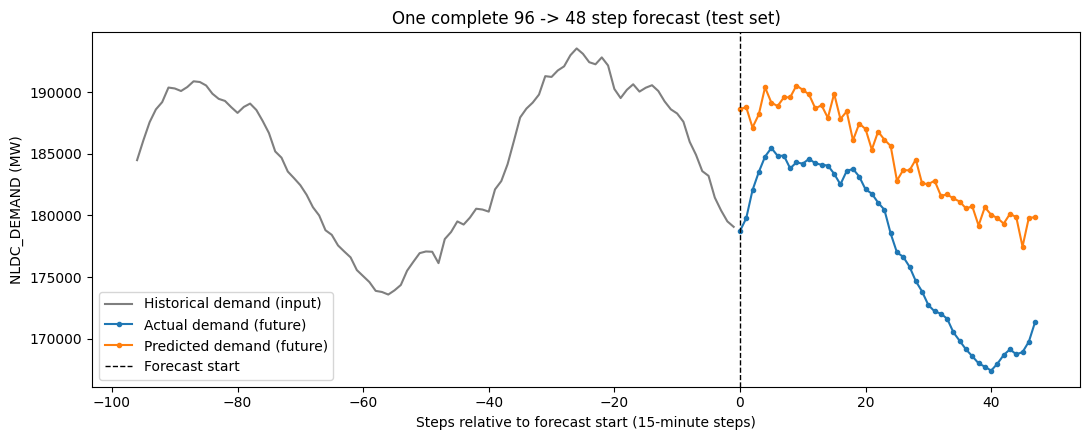

In [21]:
# Plot 1: one complete 12-hour (48-step) forecast against actual, for a single test sequence,
# with the 24 hours of history that preceded it for context.
sample_idx = len(X_test) // 2  # a sequence roughly in the middle of the test period

history_actual = target_scaler.inverse_transform(X_test[sample_idx, :, 0].reshape(-1, 1)).flatten()
forecast_actual = y_test_actual[sample_idx]
forecast_pred = y_pred[sample_idx]

steps_history = np.arange(-LOOKBACK, 0)
steps_forecast = np.arange(0, HORIZON)

plt.figure(figsize=(11, 4.5))
plt.plot(steps_history, history_actual, label="Historical demand (input)", color="tab:gray")
plt.plot(steps_forecast, forecast_actual, label="Actual demand (future)", color="tab:blue", marker="o", markersize=3)
plt.plot(steps_forecast, forecast_pred, label="Predicted demand (future)", color="tab:orange", marker="o", markersize=3)
plt.axvline(0, color="black", linestyle="--", linewidth=1, label="Forecast start")
plt.xlabel("Steps relative to forecast start (15-minute steps)")
plt.ylabel("NLDC_DEMAND (MW)")
plt.title("One complete 96 -> 48 step forecast (test set)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{MODEL_OUT_DIR}/sample_forecast.png", dpi=120)
plt.show()


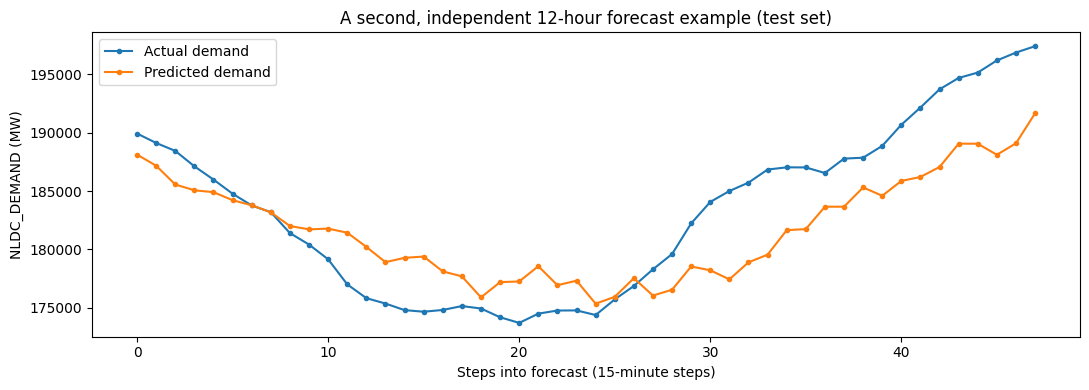

In [22]:
# Plot 2: a second, different test sequence for a sanity check that Plot 1 wasn't a lucky/unlucky pick.
sample_idx_2 = min(len(X_test) - 1, sample_idx + 500)

forecast_actual_2 = y_test_actual[sample_idx_2]
forecast_pred_2 = y_pred[sample_idx_2]

plt.figure(figsize=(11, 4))
plt.plot(steps_forecast, forecast_actual_2, label="Actual demand", color="tab:blue", marker="o", markersize=3)
plt.plot(steps_forecast, forecast_pred_2, label="Predicted demand", color="tab:orange", marker="o", markersize=3)
plt.xlabel("Steps into forecast (15-minute steps)")
plt.ylabel("NLDC_DEMAND (MW)")
plt.title("A second, independent 12-hour forecast example (test set)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{MODEL_OUT_DIR}/sample_forecast_2.png", dpi=120)
plt.show()


## 18. Save model and preprocessing artifacts

Everything the FastAPI backend will need later, saved together so inference-time preprocessing
can exactly match training-time preprocessing (Section O/Q's leakage and consistency rules apply
at inference too, not just training).

Saved to `MODEL_OUT_DIR` (`../models/lstm/`):
- `lstm_model.keras` — the trained model (architecture + weights + optimizer state)
- `target_scaler.pkl` — fitted on train `NLDC_DEMAND`; needed to scale new input demand history
  and to inverse-transform new predictions back to MW
- `feature_scaler.pkl` — fitted on train weather + day_of_month + month; needed to scale new
  input weather/calendar values the same way
- `feature_columns.json` — the exact ordered list of 33 input feature names; the backend MUST
  build its input array in this exact column order, or the model will silently misinterpret
  which column is which
- `config.json` — `LOOKBACK`, `HORIZON`, `SEASON`, and the metrics from this run, so the backend
  (and your report) know exactly what this saved model expects and how it performed


In [23]:
import pickle

model.save(f"{MODEL_OUT_DIR}/lstm_model.keras")

with open(f"{MODEL_OUT_DIR}/target_scaler.pkl", "wb") as f:
    pickle.dump(target_scaler, f)

with open(f"{MODEL_OUT_DIR}/feature_scaler.pkl", "wb") as f:
    pickle.dump(feature_scaler, f)

with open(f"{MODEL_OUT_DIR}/feature_columns.json", "w") as f:
    json.dump(FEATURE_COLUMNS, f, indent=2)

config = {
    "LOOKBACK": LOOKBACK,
    "HORIZON": HORIZON,
    "SEASON": SEASON,
    "continuous_scale_cols": CONTINUOUS_SCALE_COLS,
    "target_col": TARGET_COL,
    "trained_epochs": len(history.history["loss"]),
    "training_time_seconds": train_time_sec,
    "test_metrics": metrics,
}
with open(f"{MODEL_OUT_DIR}/config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved artifacts to:", os.path.abspath(MODEL_OUT_DIR))
for fname in sorted(os.listdir(MODEL_OUT_DIR)):
    print(" -", fname)


Saved artifacts to: C:\Users\shrey\major project\Short-Term-electricity-demand-forcasting-\models\lstm
 - config.json
 - feature_columns.json
 - feature_scaler.pkl
 - lstm_model.keras
 - sample_forecast.png
 - sample_forecast_2.png
 - target_scaler.pkl
 - training_history.png


## 19. Final results summary

A single, report-ready summary. Copy the printed values directly into your report / comparison
table against XGBoost and Transformer — do not retype them by hand from the plots.


In [24]:
print("=" * 60)
print("LSTM — FINAL TEST RESULTS")
print("=" * 60)
print(f"Lookback:        {LOOKBACK} steps (24 hours)")
print(f"Horizon:         {HORIZON} steps (12 hours)")
print(f"Trained epochs:  {len(history.history['loss'])} (early-stopped)")
print(f"Training time:   {train_time_sec:.1f} seconds")
print("-" * 60)
for k, v in metrics.items():
    print(f"{k:22s}: {v:.4f}" if isinstance(v, float) else f"{k:22s}: {v}")
print("=" * 60)
print("\nThese are this run's actual results on the real test set.")
print("Record them as-is for the model comparison phase (Member 4).")


LSTM — FINAL TEST RESULTS
Lookback:        96 steps (24 hours)
Horizon:         48 steps (12 hours)
Trained epochs:  11 (early-stopped)
Training time:   407.5 seconds
------------------------------------------------------------
MAE                   : 7778.8828
RMSE                  : 9835.1162
MAPE                  : 4.5652
R2                    : 0.1533
MASE                  : 1.7539
MASE_naive_scale_MW   : 4435.1128

These are this run's actual results on the real test set.
Record them as-is for the model comparison phase (Member 4).
